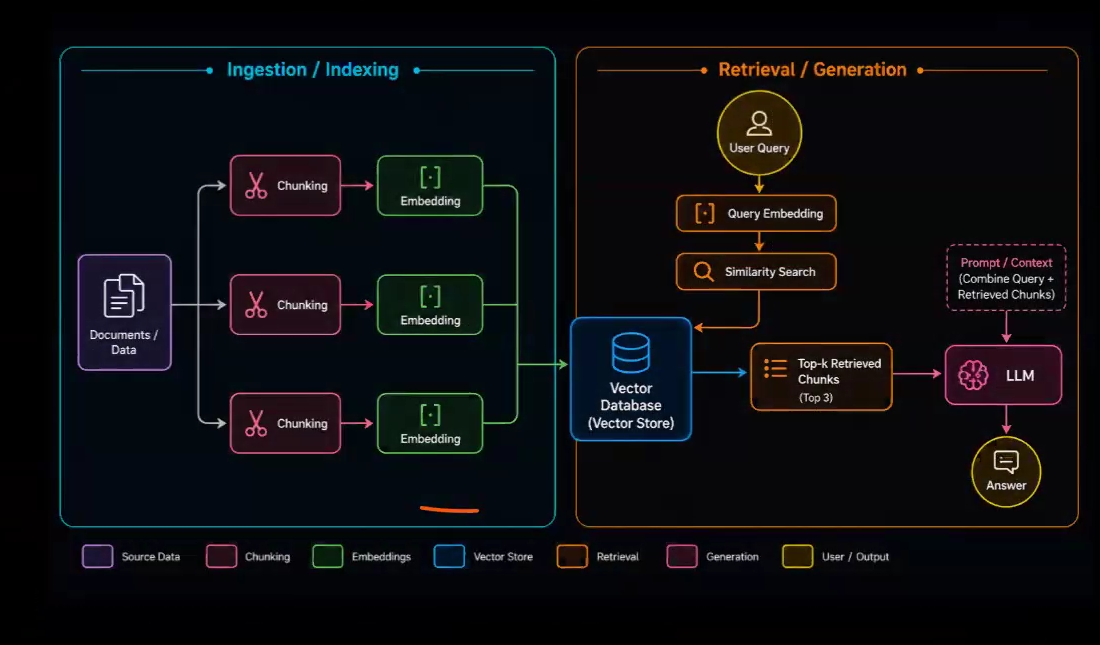

In [39]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [40]:
google_api=os.getenv("GEMINI_API_KEY")
groq_api=os.getenv("GROQ_API_KEY")

In [41]:
os.environ["GEMINI_API_KEY"] = google_api
os.environ["GROQ_API_KEY"] = groq_api
print("env variables set successfully")

env variables set successfully


In [42]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
print("embeddings model loaded successfully")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embeddings model loaded successfully


In [43]:
#testing the embeddings model
embeddings.embed_query("Hello world")

[-0.034477267414331436,
 0.031023245304822922,
 0.006735002622008324,
 0.02610897272825241,
 -0.03936199098825455,
 -0.16030247509479523,
 0.06692401319742203,
 -0.006441466510295868,
 -0.047450482845306396,
 0.014758829958736897,
 0.07087530195713043,
 0.05552758648991585,
 0.01919335499405861,
 -0.026251377537846565,
 -0.010109559632837772,
 -0.02694047801196575,
 0.022307416424155235,
 -0.02222663350403309,
 -0.1496925950050354,
 -0.01749303564429283,
 0.0076762172393500805,
 0.054352302104234695,
 0.003254439914599061,
 0.0317259281873703,
 -0.0846213549375534,
 -0.0294059868901968,
 0.051595572382211685,
 0.048124056309461594,
 -0.003314792178571224,
 -0.058279186487197876,
 0.04196929186582565,
 0.022210659459233284,
 0.128188818693161,
 -0.022338882088661194,
 -0.011656327173113823,
 0.06292837858200073,
 -0.03287631645798683,
 -0.0912260040640831,
 -0.031175334006547928,
 0.052699558436870575,
 0.04703483358025551,
 -0.08420311659574509,
 -0.0300561785697937,
 -0.02074487134814

In [44]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)

In [45]:
#testing the llm model
llm.invoke("hi how are you doing today?").content

"I'm doing great, thank you for asking! I'm ready to help you with whatever you need.\n\nHow about you? How are you doing today?"

In [46]:
#Simple ai assistant without rag pipeline
while True:
    user_input=input("user:")
    if user_input.lower()=="exit":
        print("exiting the chat Goodbye!")
        break
    response=llm.invoke(user_input).content
    print("AI:",response)

AI: "Escape" is a powerful and multifaceted word, carrying different meanings depending on the context.

Here are some common interpretations and facets of "escape":

1.  **Physical Escape:**
    *   **Definition:** To break free from confinement, danger, or an undesirable situation.
    *   **Examples:** Escaping from prison, fleeing a burning building, evading capture, running away from an abusive situation.
    *   **Motivation:** Survival, freedom, safety.

2.  **Mental/Emotional Escape:**
    *   **Definition:** To get away from reality, stress, boredom, pain, or responsibility, often through distraction or imagination.
    *   **Examples:**
        *   **Hobbies:** Reading a captivating book, playing video games, listening to music, creating art.
        *   **Travel:** Visiting new places, going on vacation.
        *   **Daydreaming:** Losing oneself in thought.
        *   **Meditation/Mindfulness:** Finding a state of inner calm away from external pressures.
        *   **Sub

d:\GEN AI BASICS\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3102: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


ValueError: contents are required.

#Here as you can see llm build a confidence but hallucinate becuase it dont have a private data thats why we need a RAG

In [ ]:
#1.Loading the data
from langchain_community.document_loaders import (
    TextLoader,
    PyPDFLoader,
    CSVLoader,
    Docx2txtLoader,
    UnstructuredHTMLLoader,
    JSONLoader,
    WebBaseLoader,
    DirectoryLoader
)
print("Execute successfully")

C:\Users\vansh_hxqeh4o\AppData\Local\Temp\ipykernel_20324\290303322.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (
USER_AGENT environment variable not set, consider setting it to identify your requests.


Execute successfully


In [ ]:
file_path = r"D:\GEN AI BASICS\RAG\DATA-PARSING\Data\deepseekv4.pdf"

In [ ]:
deepseekv4loader = PyPDFLoader(file_path)
pages = deepseekv4loader.load()

In [ ]:
len(pages)

58

2.Chunking

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
chunker = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=200)
print("Data chunking model loaded successfully")

Data chunking model loaded successfully


In [ ]:
chunked_data=chunker.split_documents(pages)
print("Data chunking completed successfully")

Data chunking completed successfully


In [ ]:
print("Total number of chunks created:",len(chunked_data))

Total number of chunks created: 588


In [ ]:
print(f"First chunk content: {chunked_data[0].page_content}")

First chunk content: DeepSeek-V4:
Towards Highly Efficient Million-Token Context Intelligence
DeepSeek-AI
research@deepseek.com
Abstract
We present a preview version of DeepSeek-V4 series, including two strong Mixture-of-
Experts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and
DeepSeek-V4-Flash with 284B parameters (13B activated) — both supporting a context length of
one million tokens. DeepSeek-V4 series incorporate several key upgrades in architecture and op-


2.Vector-Database

In [ ]:
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore
print("FAISS model loaded successfully")

FAISS model loaded successfully


In [ ]:
index=faiss.IndexFlatL2(384)

In [ ]:
vectorstore=FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={}
)

In [ ]:
vectorstore.add_documents(chunked_data)

['c00c906d-9b2b-419f-b41c-26b859c09cb8',
 '41f57f05-cee3-49a3-84c8-8242bf27cd44',
 '9bd23ed3-9316-46ae-a652-cc683071c3ed',
 'e36afa1e-5b29-46fb-8f98-5f99872703f9',
 '3d3c47b1-7335-4dc8-bd26-514bc94c9ce6',
 '4102ea96-54c8-4dfb-af8b-ca155fedb893',
 '5ada1873-ef54-41cf-acab-db32a24bb3d0',
 '4547670c-c87c-4490-93d1-7e37dfb0a647',
 '1f390c19-cfa8-47ef-be12-c2131cad226a',
 '4dd3c27c-5fd0-45e7-8555-fcae2a519fcf',
 '97aedfce-11f0-4adb-8319-afd408a5be53',
 '8953ee3c-8673-4bda-9847-7b0250c02ddb',
 '857631fb-e36a-45dc-ace5-a07a2c8324fd',
 '38662396-8bcd-4170-82a6-fdb22ab9cd38',
 'ca4e4d3c-4925-46e7-a2e4-11096fab9332',
 '5fc4b31b-fb4a-44e9-99dc-d1e3ea4d1e3e',
 '8b79462e-c823-41b5-991b-da1fec0ccc50',
 '029e1e43-3273-469a-badf-d71afa36356f',
 'de53f006-0a49-4279-b180-dadc64ced357',
 '8f64da84-9328-49af-9b7b-d26e5e2552f2',
 '1b4c604e-0575-4205-ad34-7958cff721f6',
 'f748ce8e-ac1e-4109-b5c5-7c298ad01a04',
 'e2800ae4-8e29-452f-9287-64bab8f6615d',
 '1ff4060e-a332-4043-b513-cd36c681c771',
 'd68a50f6-8530-

In [56]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [57]:
retriever.invoke("What is this deepseekv4 model about?")

[Document(id='0669b050-0503-45dd-a812-2922059aa7f0', metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; 

In [58]:
template="""Answer the question based only on the  following context below:
{context}
question: {question}
"""

In [59]:
from langchain_core.prompts import PromptTemplate
prompt=PromptTemplate.from_template(template)

In [60]:
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the  following context below:\n{context}\nquestion: {question}\n')

# RAG Chain
rag_chain = prompt | model | StrOutputParser()

**What is `prompt`?**<br>
`prompt` is a `PromptTemplate` object that defines the structure of the prompt sent to the language model.<br><br>

**What is `model`?**<br>
`model` is a Language Model (LLM) that generates a response based on the prompt provided.<br><br>

**What is `StrOutputParser()`?**<br>
`StrOutputParser()` is an output parser that converts the model's response into a plain string.

**What is `RunnablePassthrough()`?**<br>

`RunnablePassthrough()` passes the user's input to the next step **without making any changes**.

In [61]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

In [62]:
def format_docs(docs):
    return "\n".join([doc.page_content for doc in docs])

In [63]:
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [65]:
rag_chain.invoke("how many parameters are there in the DeepSeek-V4 pro model?")

'DeepSeek-V4-Pro comprises 1.6T total parameters.'